# 🎓 Predicting Student Mental Health Score from Social Media Usage

**Problem:** We're predicting a student's `Mental_Health_Score` (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a **regression** problem since the target is a number, not a category.

**Dataset:** `Student_Social_Media_And_Mental_Health_Impact.csv` — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.



## 1. Importing Libraries



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MLP iitm/Datasets/Student Social Media And Mental Health Impact.csv')

## 3. Dataset Inspection

### 🔍 Initial ExplorationQuick look at the data: first rows, shape, dtypes/non-null counts, and summary statistics for numeric and categorical columns.

In [ ]:
df.shape

(5000, 13)

In [ ]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


### Checking for null values

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


### Check for Duplicates

In [ ]:
df.duplicated().sum()

np.int64(2)

### Descriptive Statistics of Numerical columns

In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


📌 **Reading this:** Most columns look reasonable — but look closely at `Physical_Activity_Hours`: the **minimum value is -0.4**. Negative hours aren't physically possible, so this is a data-entry glitch, not a real value. We'll fix this properly in the **Data Cleaning** step instead of ignoring it.

## 4. Exploratory Data Analysis (EDA)

### 4.1 — Distribution of the target (`Mental_Health_Score`)

Before predicting anything, we need to understand the shape of what we're predicting.

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

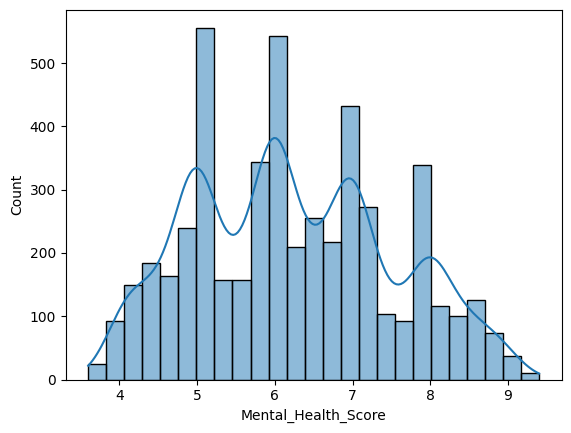

In [ ]:
sns.histplot(df['Mental_Health_Score'],kde=True)

### 4.2 — Correlation heatmap

Which numeric features actually move together with the target?

<Axes: >

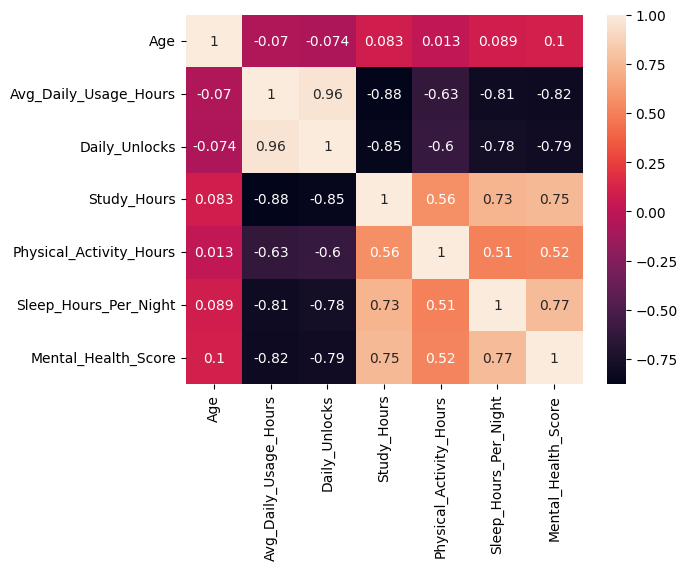

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

### 4.3 — Stress Level vs Mental Health Score

Does higher stress genuinely come with a lower score?

In [ ]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

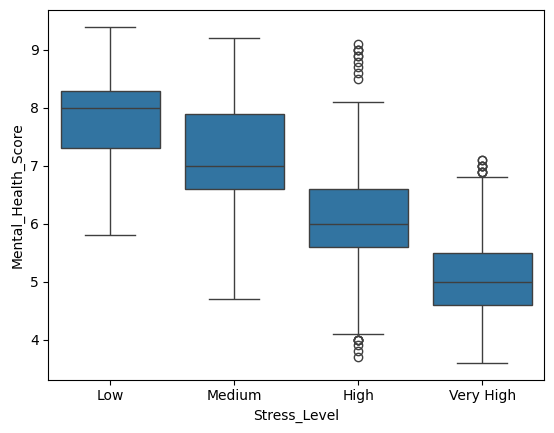

In [ ]:
order=['Low','Medium','High','Very High']
sns.boxplot(x=df['Stress_Level'],y=df['Mental_Health_Score'],order=order)
#The more the stress level less the mental health score.

### 4.4 — Daily Usage Hours vs Mental Health Score

Does more time on social media relate to a lower score?

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

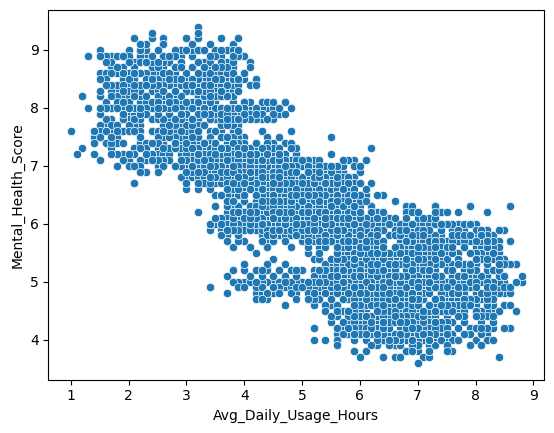

In [ ]:
sns.scatterplot(x=df['Avg_Daily_Usage_Hours'],y=df['Mental_Health_Score'])
# The more the avg usage hours the less the score

### 4.5 — Sleep Hours vs Mental Health Score

Sleep is one of the most commonly cited mental health factors — does the data back that up?

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

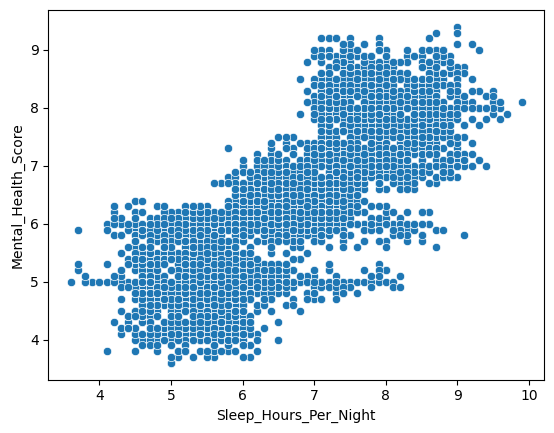

In [ ]:
sns.scatterplot(x=df['Sleep_Hours_Per_Night'],y=df['Mental_Health_Score'])
#The more sleep the better the score

### 4.6 — Most Used Platform (count)

A quick look at which platforms are most common in our dataset.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Instagram'),
  Text(1, 0, 'TikTok'),
  Text(2, 0, 'Facebook'),
  Text(3, 0, 'LinkedIn'),
  Text(4, 0, 'YouTube'),
  Text(5, 0, 'Twitter'),
  Text(6, 0, 'Snapchat'),
  Text(7, 0, 'WhatsApp'),
  Text(8, 0, 'LINE'),
  Text(9, 0, 'VKontakte'),
  Text(10, 0, 'KakaoTalk'),
  Text(11, 0, 'WeChat')])

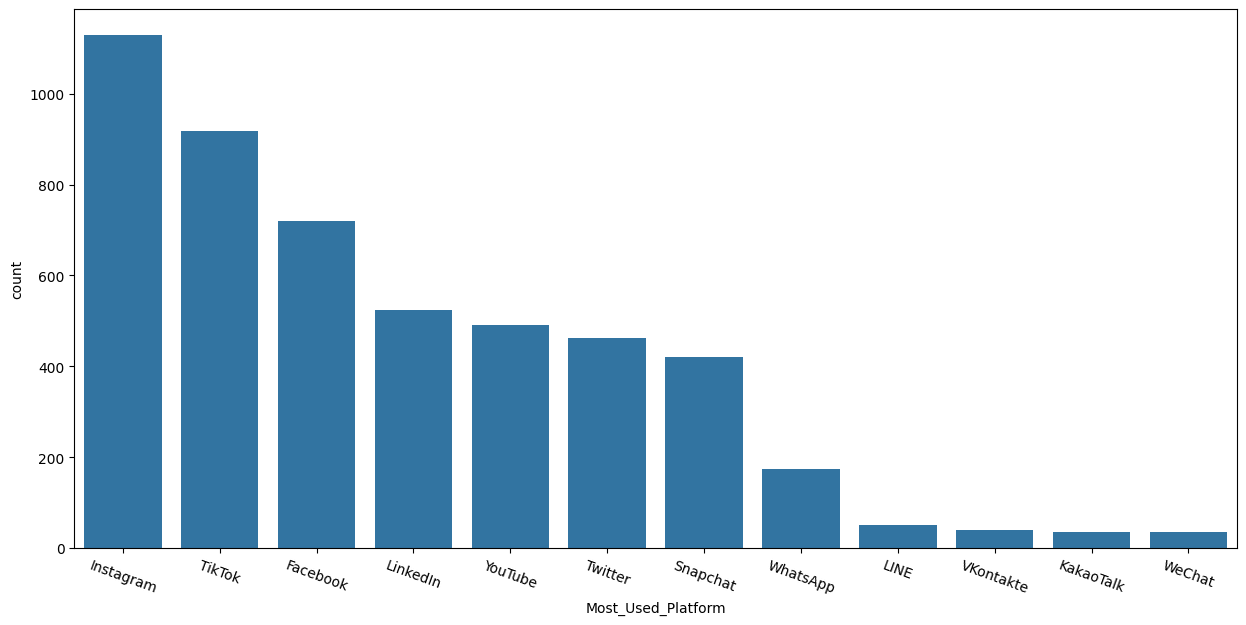

In [ ]:
plt.figure(figsize=(15,7))
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation=-20)

### 📊 Outlier Detection (IQR Method)Flagging outliers per numeric column using the 1.5×IQR rule. Outliers are intentionally kept since tree-based models are relatively robust to them.

In [ ]:
# Select only numerical columns from your dataframe
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

outlier_summary = {}

for col in num_cols:
    # Skip columns that are entirely null
    if df[col].isnull().all():
        continue

    # Calculating Q1, Q3, and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Defining upper and lower bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    valid_data = df[col].dropna()
    total_count = len(valid_data)

    # Identify outliers
    outliers = valid_data[(valid_data < lower_bound) | (valid_data > upper_bound)]
    outlier_count = len(outliers)

    # Calculate percentage
    outlier_percentage = (outlier_count / total_count) * 100 if total_count > 0 else 0

    # storing results
    outlier_summary[col] = {
        'Total Valid Rows': total_count,
        'Outlier Count': outlier_count,
        'Outlier Percentage (%)': round(outlier_percentage, 3)
    }


outlier_df = pd.DataFrame(outlier_summary).T
display(outlier_df)

,Total Valid Rows,Outlier Count,Outlier Percentage (%)
Age,5000.0,0.0,0.00
Avg_Daily_Usage_Hours,5000.0,0.0,0.00
Daily_Unlocks,5000.0,0.0,0.00
Study_Hours,5000.0,2.0,0.04
Physical_Activity_Hours,5000.0,22.0,0.44
Sleep_Hours_Per_Night,5000.0,0.0,0.00
Mental_Health_Score,5000.0,0.0,0.00


## 5. Data Cleaning

Two real issues to fix here — everything else in this dataset is already clean.

In [ ]:
# 1 Dropping Duplicates
df.drop_duplicates(inplace=True)

In [ ]:
#2 clipping the lower bound of the column Physical_Activity_Hours because it has an unrealistic minimum value -0.4 that we checked before ,During initial Data inspection
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)


📌 **Why `clip(lower=0)` and not dropping the row:** the rest of that student's data (age, study hours, stress level, etc.) is still valid and useful — throwing away the whole row over one bad value wastes good data. Clipping caps the impossible value at the nearest realistic one (0 hours) without discarding everything else about that student.

We're not dropping any columns either — every column here has a plausible reason to matter for predicting mental health, and we already confirmed none of them are empty or constant.

## 6. Skewness

**What skewness is:** a measure of how lopsided a numeric column's distribution is. A value near 0 means roughly symmetric (bell-shaped); a large positive or negative value means the data leans heavily to one side, with a long tail.

**Why it matters:** models like Linear Regression assume features are roughly well-behaved. A heavily skewed column (think: a long tail of extreme values) can quietly drag the model's predictions in that direction. Tree-based models like Random Forest don't care about skew — but since we're also training a Linear Regression baseline, it's worth fixing.

In [ ]:
num_cols = df.select_dtypes(include='number')
num_cols.skew()
# We will try to fix Study hours as it is somewhat Right skewed

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


<Axes: xlabel='Study_Hours', ylabel='Count'>

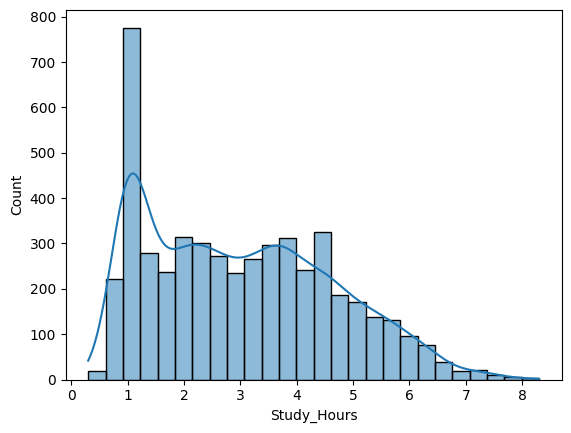

In [ ]:

sns.histplot(df['Study_Hours'],kde=True)

## 7. Feature Engineering

**One meaningful engineered feature here:** grouping `Country`.

- `Country` has **111 unique values** in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
- Dropping `Country` entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.
- **The fix:** keep the top 10 most frequent countries as their own category, and bucket everything else into `"Other"`. We keep the signal that matters and lose the noise that doesn't.

In [ ]:
top_countries=df['Country'].value_counts().index[:10].tolist()

In [ ]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [ ]:
df['Country']=df['Country'].apply(group_countries)
df['Country'].nunique()

10

📌 **Result:** we went from 111 raw categories down to 11 manageable ones (10 countries + "Other"). This is exactly the kind of decision that separates a project that "just ran `pd.get_dummies()`" from one that actually thought about the data.

## 8. Encoding Strategy

Before we jump into code, let's decide *how* each categorical column should be encoded — this decision matters more than the code itself.

- **`Stress_Level` → Ordinal Encoding.** Its categories have a real, meaningful order: Low < Medium < High < Very High. We already saw in EDA (section 4.3) that the score drops step by step as stress increases — encoding it as 0, 1, 2, 3 preserves that order for the model.
- **`Gender`, `Academic_Level`, `Most_Used_Platform`, `Purpose_Of_Use`, `Country_Grouped` → One-Hot Encoding.** These categories have **no natural order** — "Instagram" isn't "greater than" "LinkedIn". One-hot encoding creates a separate 0/1 column per category so the model doesn't accidentally assume a false ranking.

We'll implement both of these inside a single `ColumnTransformer` in the next step, rather than doing it manually column by column — that keeps preprocessing consistent and reusable.

## 9. Train-Test Split

**Why we split:** we need data the model has never seen to honestly check how well it generalizes. If we evaluate on the same data we trained on, the model can just "memorize" the answers and look artificially good.

**Common ratios:** 80/20 or 70/30 are both standard. We'll use an 80/20 split here — with 5,000 rows, that still leaves 1,000 rows for a solid, reliable test.

We split **before** fitting any preprocessing — this is the single most common beginner mistake (called data leakage), and we'll avoid it by fitting everything only on the training set.

In [ ]:
from sklearn.model_selection import train_test_split

skewed_cols = ['Study_Hours'] # columns that are skewed

other_num_cols = ['Age','Avg_Daily_Usage_Hours','Daily_Unlocks','Physical_Activity_Hours','Sleep_Hours_Per_Night'] # normal numerical columns other than skewed

ordinal_cols = ['Stress_Level'] # columns in which we have to apply ordinal encoding to preserve order

one_hot_columns = ['Gender','Country','Academic_Level','Most_Used_Platform','Purpose_Of_Use'] # columns in which we have to apply one hot encoding

feature_cols = skewed_cols + other_num_cols + ordinal_cols + one_hot_columns

X=df[feature_cols] # X our feature columns
y=df['Mental_Health_Score'] # y Our target column

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

## 10. Preprocessing using ColumnTransformer

Our columns need **different treatment**:

- `Study_Hours` (the skewed one) → impute → `log1p` transform → scale
- The other numeric columns → impute → scale (no skew to fix)
- `Stress_Level` → impute → `OrdinalEncoder` with an **explicit order**
- The nominal columns → impute → `OneHotEncoder`

We include a `SimpleImputer` in every branch even though this dataset has zero missing values right now — it's a safety net. Real-world data (and our future API's incoming requests) won't always be this clean, and a pipeline that assumes "no missing values ever" is a pipeline that breaks in production.

`ColumnTransformer` glues all of this into **one object** that applies the right transformation to the right column type in a single `.fit()` / `.transform()` call — no manual column-by-column juggling.

In [ ]:
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,FunctionTransformer

In [ ]:
skewed_pipeline = Pipeline(
    [
        ('skewness',FunctionTransformer(np.log1p)),
        ('scaler',StandardScaler())
    ]
)

#Other numeric features
other_num_pipeline = Pipeline(
    [
        ('Scaler',StandardScaler())
    ]
)

# Ordinal features
Ordinal_cols_pipeline = Pipeline(
    [
        ('ordinalencoding',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
    ]
)

# Nominal Features
one_hot_cols_pipeline = Pipeline(
    [
        ('onehotencoding',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [ ]:
Preprocessor = ColumnTransformer(transformers=[
    ('skew_transformer',skewed_pipeline,skewed_cols),
    ('Numeric_Transformer',other_num_pipeline,other_num_cols),
    ('Ordinal_transformer',Ordinal_cols_pipeline,ordinal_cols),
    ('One_hot_transformer',one_hot_cols_pipeline,one_hot_columns)
],remainder='passthrough')
Preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('skew_transformer',
                                 Pipeline(steps=[('skewness',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Study_Hours']),
                                ('Numeric_Transformer',
                                 Pipeline(steps=[('Scaler', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal_transformer',
                                 Pipeline(steps=[('ordinalencoding',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('One_hot_transformer',
                                 Pipeline(steps=[('onehotencoding',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Country', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use'])])

## 11. Building Pipelines

**Why Pipeline matters:** a `Pipeline` chains preprocessing and the model into a single object. Calling `.fit()` once does both steps in the correct order, and calling `.predict()` on brand-new raw data automatically applies the exact same preprocessing that was used during training — no risk of forgetting a step or applying it inconsistently.

when this model gets deployed the API doesn't need to know *anything* about scaling, encoding, or log transforms — it just loads one saved pipeline object and calls `.predict()` on raw input. That's a huge reduction in what can go wrong in production.

We'll build two pipelines below — one per model — so we can fairly compare them.

## 12. Model Building

We're comparing **two models** here because the comparison itself teaches something useful — a plain Linear Regression baseline versus a Random Forest, which can capture the non-linear patterns we spotted back in EDA (section 4.4).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

### 12.1 — Baseline: Linear Regression

In [ ]:
lr = LinearRegression()
lr_pipeline = Pipeline(
    [
        ('transformer',Preprocessor),
        ('linregr',LinearRegression())
    ]
)

lr_pipeline.fit(X_train,y_train)
y_preds=lr_pipeline.predict(X_test)

#Test Losses
test_mae = mean_absolute_error(y_test,y_preds)
test_r2=r2_score(y_test,y_preds)
test_mse = mean_squared_error(y_test,y_preds)

#Training loss R2
train_preds = lr_pipeline.predict(X_train)
train_r2 = r2_score(y_train,train_preds)

result={}

result['Linear Regression'] = {
    'R2 Score': test_r2,
    'MAE ' : test_mae,
    'MSE' : test_mse
}

result_df = pd.DataFrame(result).T
print(f'----------------- Test Results -----------------')
result_df

----------------- Test Results -----------------


,R2 Score,MAE,MSE
Linear Regression,0.739794,0.536178,0.457019


#### Comparing Training And Testing R2

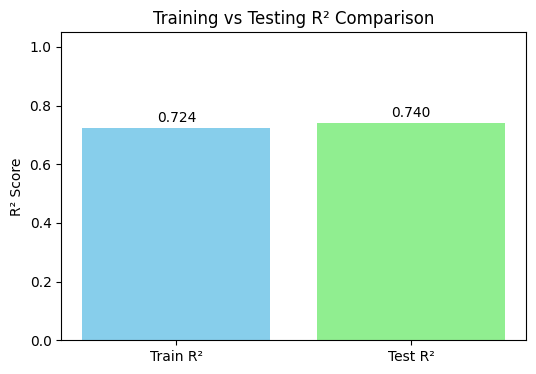

In [ ]:
import matplotlib.pyplot as plt

# Values
scores = [train_r2, test_r2]
labels = ['Train R²', 'Test R²']

# Plot
plt.figure(figsize=(6,4))
plt.bar(labels, scores, color=['skyblue','lightgreen'])

# Add labels on bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.ylim(0, 1.05)
plt.ylabel('R² Score')
plt.title('Training vs Testing R² Comparison')
plt.show()


### 12.2 — More Models (default settings)

#### Training & Evaluating All  Models Each model is wrapped with the shared preprocessing pipeline, fit on the training split, and scored on the validation split using R² ,MAE and RMSE.

In [ ]:
models = {
    'KNN' : KNeighborsRegressor(),
    'Decision_tree' : DecisionTreeRegressor(random_state=42),
    'Random_Forest' : RandomForestRegressor(random_state=42,n_jobs=-1),
    'XGBoost'       : XGBRegressor(random_state=42,n_jobs=-1),
    'lgbm'          : LGBMRegressor(random_state=42,n_jobs=-1,verbosity=-1)
}

results={}

for name,model in models.items():
  #Training and evaluating
  pipeline = make_pipeline(Preprocessor,model)

  #fitting the model
  pipeline.fit(X_train,y_train)

  #predicting
  y_pred=pipeline.predict(X_test)

  #Scoring
  r2 = r2_score(y_test,y_pred)
  rmse = root_mean_squared_error(y_test,y_pred)
  mae = mean_absolute_error(y_test,y_pred)

  results[name] = {
      'R2 Score' : r2,
      'RMSE'     : rmse,
      'MAE'      : mae
  }


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 13. Model Evaluation

**Metrics, explained simply:**
- **R² Score** — how much of the variation in mental health scores our model explains, from 0 (useless) to 1 (perfect). 0.85 means the model explains 85% of the pattern.
- **MAE (Mean Absolute Error)** — on average, how far off our prediction is, in the original units (score points). Easy to explain to a non-technical person.
- **RMSE (Root Mean Squared Error)** — similar to MAE, but penalizes big mistakes more heavily. Useful for spotting whether a model makes a few very wrong predictions.



#### Leaderboard Ranking the  models by validation R² score.

In [ ]:
performance_df = pd.DataFrame(results).T

#  Sorting by R2 Score (Highest to Lowest)
performance_df = performance_df.sort_values(by='R2 Score',ascending=False)

print("------- Model Performance Leaderboard -------")
display(performance_df)

------- Model Performance Leaderboard -------


,R2 Score,RMSE,MAE
Random_Forest,0.877211,0.464396,0.347760
XGBoost,0.877142,0.464527,0.351994
lgbm,0.847003,0.518382,0.403930
KNN,0.840021,0.530078,0.383587
Decision_tree,0.757247,0.652968,0.420333


## 14. Hyperparameter Tuning of our top tier 3 models Random forest , Xg boost , Light bgm

### As we can see Random Forest is performing the best followed by XGBoost and lgbm so we will perform Hyperparameter Tuning of our Top 3 Best MOdels.


### XgBoost Hyperparameter Tuning
### XGBoost Hyperparameter TuningGridSearchCV over **max_depth**, **n_estimators**, and **learning_rate**. Results are collected in a results dict so all three tuned models (XGBoost, Random Forest, LightGBM) can be compared later.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform,randint

In [ ]:
xgb_tuned_pipeline = Pipeline([
    ('preprocessor',Preprocessor),
    ('xgb_tuned',XGBRegressor(random_state=42,n_jobs=-1))
])

#param grid for xgb tuning
xgb_params = {
    'xgb_tuned__n_estimators' : randint(100,1000),
    #Learning Rate
    'xgb_tuned__learning_rate' : uniform(0.01, 0.29),
    #Tree complexity
    'xgb_tuned__max_depth': randint(3, 12),
    # Minimum loss reduction required for a split
    'xgb_tuned__gamma': uniform(0, 5),
    # Minimum sum of instance weight in a child
    'xgb_tuned__min_child_weight': randint(1, 15)

}

xgb_tuned = RandomizedSearchCV(
    xgb_tuned_pipeline,
    xgb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    n_iter=15
    )

xgb_tuned.fit(X_train, y_train)

tuned_model = xgb_tuned.best_estimator_
y_pred = tuned_model.predict(X_test)
r2 = round(r2_score(y_test,y_pred), 4)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))



In [ ]:
results = {}
results["XGBoost (tuned)"] = {"R2": r2, "RMSE": rmse}

print("Best XGB Regressor Params:", xgb_tuned.best_params_)
print("XGBRegressor R²:", r2 )

Best XGB Regressor Params: {'xgb_tuned__gamma': np.float64(0.06434322186086472), 'xgb_tuned__learning_rate': np.float64(0.25364443755541627), 'xgb_tuned__max_depth': 6, 'xgb_tuned__min_child_weight': 1, 'xgb_tuned__n_estimators': 550}
XGBRegressor R²: 0.8546


### Random Forest Tuning RandomizedSearchCV .

In [ ]:
rf_tuned_pipeline = make_pipeline(Preprocessor,RandomForestRegressor(random_state=42,n_jobs=-1))

rf_param_grid = {
    'randomforestregressor__n_estimators': randint(100, 1000),
    'randomforestregressor__max_depth': [5, 10, 15, 20, 30, 40],
    'randomforestregressor__min_samples_split': randint(2, 20),
    'randomforestregressor__min_samples_leaf': randint(1, 10),
}
rf_tuned = RandomizedSearchCV(
    rf_tuned_pipeline,
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    n_iter=15
    )

rf_tuned.fit(X_train, y_train)

tuned_model = rf_tuned.best_estimator_
y_pred = tuned_model.predict(X_test)
r2 = round(r2_score(y_test,y_pred), 4)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))



In [ ]:

results["Random Forest (tuned)"] = {"R2": r2, "RMSE": rmse}

print("Best Random Forest Regressor Params:", rf_tuned.best_params_)
print("Random Forest R²:", r2)

Best Random Forest Regressor Params: {'randomforestregressor__max_depth': 30, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__min_samples_split': 9, 'randomforestregressor__n_estimators': 693}
Random Forest R²: 0.862


### LightGBM Tuning RandomizedSearchCV.

In [ ]:
lgbm_tuned_pipeline = make_pipeline(Preprocessor, LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1))

lgbm_param_grid = {
    'lgbmregressor__n_estimators': randint(100, 1000),
    'lgbmregressor__learning_rate': uniform(0.01, 0.29),
    'lgbmregressor__max_depth': randint(3, 15),
    'lgbmregressor__num_leaves': randint(10, 150),
    'lgbmregressor__min_child_samples': randint(5, 100),
    'lgbmregressor__min_split_gain': uniform(0, 5)
}

lgbm_tuned = RandomizedSearchCV(
    lgbm_tuned_pipeline,
    lgbm_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    n_iter=15
    )

lgbm_tuned.fit(X_train, y_train)

tuned_model = lgbm_tuned.best_estimator_
y_pred = tuned_model.predict(X_test)
r2 = round(r2_score(y_test,y_pred), 4)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
results["Lgbm(tuned)"] = {"R2": r2, "RMSE": rmse}

print("Best Lgbm Regressor Params:", lgbm_tuned.best_params_)
print("LgbmRegressor R²:", r2)

Best Lgbm Regressor Params: {'lgbmregressor__learning_rate': np.float64(0.07422554318953847), 'lgbmregressor__max_depth': 13, 'lgbmregressor__min_child_samples': 48, 'lgbmregressor__min_split_gain': np.float64(0.35094703467364874), 'lgbmregressor__n_estimators': 992, 'lgbmregressor__num_leaves': 131}
LgbmRegressor R²: 0.8105


In [ ]:
tuned_performance_df = pd.DataFrame(results).T
tuned_performance_df = tuned_performance_df.sort_values(by='R2', ascending=False)
print("--- Tuned Model Leaderboard ---")

display(tuned_performance_df)

best_model_name = tuned_performance_df.index[0]
print(f"\nBest tuned model: {best_model_name}")

--- Tuned Model Leaderboard ---


,R2,RMSE
Random Forest (tuned),0.8620,0.492354
XGBoost (tuned),0.8546,0.505312
Lgbm(tuned),0.8105,0.576943



Best tuned model: Random Forest (tuned)


## 15. 🏁 Final Model Training As we can see the Best model is Default Random Forest. So we will train our og random Forest on Full Data.

In [ ]:
# Concatenate row-wise
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

print(f"Training final model Random Forest Default on 100% of the training data...")

final_rf_pipeline = make_pipeline(Preprocessor,RandomForestRegressor(random_state=42,n_jobs=-1))

#fitting the model
final_rf_pipeline.fit(X_full,y_full)



Training final model Random Forest Default on 100% of the training data...


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('skew_transformer',
                                                  Pipeline(steps=[('skewness',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('Numeric_Transformer',
                                                  Pipeline(steps=[('Scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Phy...
                                                  Pipeline(steps=[('ordinalencoding',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('One_hot_transformer',
                                                  Pipeline(steps=[('onehotencoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Country',
                                                   'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use'])])),
                ('randomforestregressor',
                 RandomForestRegressor(n_jobs=-1, random_state=42))])

## 16. Save the Model

We save the **entire pipeline** — preprocessing and model together — as a single file, not just the raw model. **Why:** if we only saved the Random Forest object, our FastAPI backend would need to manually recreate every encoding and scaling step by hand at prediction time, which is fragile and easy to get wrong. Saving the full pipeline means the backend just loads one file and calls `.predict()` on raw input — the pipeline handles everything internally, exactly the same way it did during training.

In [ ]:
import joblib
joblib.dump(final_rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']